<a href="https://colab.research.google.com/github/rezar362/Portfolio/blob/main/instacart_optimizer_gnn_rl/instacart_optimizer_gnn_rl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
import os, json
from pathlib import Path
import datetime

drive.mount('/content/drive')

# ── Persistent root ──────────────────────────────────────────
BASE_DIR = Path('/content/drive/MyDrive/SF_Delivery_Optimization')
DIRS = {
    'data':        BASE_DIR / 'data',
    'graph':       BASE_DIR / 'data/graph',
    'orders':      BASE_DIR / 'data/orders',
    'models':      BASE_DIR / 'models',
    'checkpoints': BASE_DIR / 'checkpoints',
    'results':     BASE_DIR / 'results',
    'plots':       BASE_DIR / 'plots',
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

# ── Config (shared across sessions) ──────────────────────────
CONFIG_PATH = BASE_DIR / 'config.json'
if not CONFIG_PATH.exists():
    config = {
        'version':         '1.0',
        'city':            'San Francisco, CA',
        'n_warehouses':    3,
        'n_neighborhoods': 15,
        'gnn_epochs':      100,
        'rl_timesteps':    200_000,
        'seed':            42,
        'created_at':      datetime.datetime.now().isoformat(),
    }
    CONFIG_PATH.write_text(json.dumps(config, indent=2))
    print("✅ Config created")
else:
    config = json.loads(CONFIG_PATH.read_text())
    print(f"✅ Config loaded (created {config['created_at'][:10]})")

print("\n📁 Storage layout:")
for k, v in DIRS.items():
    print(f"   {k:12s} → {v}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Config loaded (created 2026-04-26)

📁 Storage layout:
   data         → /content/drive/MyDrive/SF_Delivery_Optimization/data
   graph        → /content/drive/MyDrive/SF_Delivery_Optimization/data/graph
   orders       → /content/drive/MyDrive/SF_Delivery_Optimization/data/orders
   models       → /content/drive/MyDrive/SF_Delivery_Optimization/models
   checkpoints  → /content/drive/MyDrive/SF_Delivery_Optimization/checkpoints
   results      → /content/drive/MyDrive/SF_Delivery_Optimization/results
   plots        → /content/drive/MyDrive/SF_Delivery_Optimization/plots


In [7]:
!pip install -q osmnx networkx folium stable-baselines3 gymnasium torch-geometric

In [9]:
import os, json, pickle, time, random, warnings
import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
import folium
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.utils import to_undirected

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# ── Reproducibility ──────────────────────────────────────────
SEED = config['seed']
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Imports done")
print(f"🖥️  Device: {DEVICE}")
print(f"🔦 PyTorch: {torch.__version__}")


# ── GNN Model ────────────────────────────────────────────────
class DeliveryGNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, extra_feat_dim, hidden_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Edge attr projection to match hidden dim
        self.edge_proj = nn.Linear(edge_feat_dim, hidden_dim)

        # Graph conv layers
        self.conv1 = GATConv(node_feat_dim, hidden_dim, edge_dim=hidden_dim)
        self.conv2 = GATConv(hidden_dim, hidden_dim, edge_dim=hidden_dim)

        # Final predictor: zone embedding + extra route features
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + extra_feat_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, edge_index, edge_attr, extra_features, batch):
        # Project edge attributes
        edge_attr = self.edge_proj(edge_attr)

        # GNN message passing
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)

        # Per-edge destination zone embedding
        zone_embeddings = x[edge_index[1]]        # [total_edges, hidden_dim]

        # Expand extra_features to match total edges using batch vector
        edge_batch = batch[edge_index[1]]          # which graph each edge belongs to
        extra_expanded = extra_features[edge_batch] # [total_edges, extra_feat_dim]

        combined = torch.cat([zone_embeddings, extra_expanded], dim=1)
        return self.fc(combined).squeeze()


# ── Training loop ─────────────────────────────────────────────
def train_gnn(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.extra_features,  # shape: [batch_size, extra_feat_dim]
            batch.batch            # PyG batch vector
        )

        loss = criterion(pred, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_gnn(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr,
                batch.extra_features,
                batch.batch
            )
            loss = criterion(pred, batch.y)
            total_loss += loss.item()
    return total_loss / len(loader)


def run_training(model, train_loader, val_loader, device, epochs=100, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5, verbose=True
    )

    best_val_loss = float('inf')
    history = {'train': [], 'val': []}

    print("── Training GNN ──")
    for epoch in range(1, epochs + 1):
        train_loss = train_gnn(model, train_loader, optimizer, criterion, device)
        val_loss   = eval_gnn(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history['train'].append(train_loss)
        history['val'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), DIRS['models'] / 'gnn_best.pt')

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | train {train_loss:.4f} | val {val_loss:.4f}")

    # Save final + history
    torch.save(model.state_dict(), DIRS['models'] / 'gnn_final.pt')
    with open(DIRS['models'] / 'gnn_history.json', 'w') as f:
        json.dump(history, f)

    print(f"\n✅ Training complete — best val loss: {best_val_loss:.4f}")
    print(f"💾 Model saved to {DIRS['models']}")
    return history

✅ Imports done
🖥️  Device: cuda
🔦 PyTorch: 2.10.0+cu128


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
import osmnx as ox
import pickle
from pathlib import Path

# ── Settings ─────────────────────────────────────────────────
GRAPH_PATH    = DIRS['graph'] / 'sf_road_network.pkl'
GRAPHML_PATH  = DIRS['graph'] / 'sf_road_network.graphml'

# ── 15 SF neighborhoods + 3 warehouse locations ──────────────
NEIGHBORHOODS = {
    'Mission':          (37.7599,  -122.4148),
    'Castro':           (37.7609,  -122.4350),
    'SoMa':             (37.7785,  -122.3948),
    'Financial':        (37.7946,  -122.3999),
    'Chinatown':        (37.7941,  -122.4078),
    'North Beach':      (37.8061,  -122.4103),
    'Marina':           (37.8030,  -122.4360),
    'Richmond':         (37.7785,  -122.4830),
    'Sunset':           (37.7525,  -122.4877),
    'Haight':           (37.7692,  -122.4481),
    'Noe Valley':       (37.7502,  -122.4327),
    'Excelsior':        (37.7247,  -122.4233),
    'Bayview':          (37.7317,  -122.3890),
    'Tenderloin':       (37.7838,  -122.4143),
    'Potrero Hill':     (37.7590,  -122.3986),
}

WAREHOUSES = {
    'WH_North':   (37.8044,  -122.4156),  # near Fishermans Wharf
    'WH_Central': (37.7749,  -122.4194),  # Civic Center
    'WH_South':   (37.7330,  -122.3890),  # Bayview industrial
}

# ── Download or load from Drive cache ────────────────────────
if GRAPH_PATH.exists():
    print("📂 Loading cached road network from Drive...")
    with open(GRAPH_PATH, 'rb') as f:
        G = pickle.load(f)
    print(f"✅ Loaded: {len(G.nodes):,} nodes, {len(G.edges):,} edges")

else:
    print("🌐 Downloading SF road network from OpenStreetMap...")
    G = ox.graph_from_place(
        'San Francisco, California, USA',
        network_type='drive',
        simplify=True
    )

    # Add travel time to each edge (seconds)
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)

    # Save both formats to Drive
    with open(GRAPH_PATH, 'wb') as f:
        pickle.dump(G, f)
    ox.save_graphml(G, filepath=str(GRAPHML_PATH))

    print(f"✅ Downloaded & cached: {len(G.nodes):,} nodes, {len(G.edges):,} edges")
    print(f"💾 Saved to {GRAPH_PATH}")


# ── Snap warehouses + neighborhoods to nearest graph node ────
def snap_to_graph(G, locations: dict) -> dict:
    snapped = {}
    for name, (lat, lng) in locations.items():
        node_id = ox.nearest_nodes(G, X=lng, Y=lat)
        snapped[name] = {
            'node_id': node_id,
            'lat':     G.nodes[node_id]['y'],
            'lng':     G.nodes[node_id]['x'],
            'label':   name,
        }
    return snapped

WAREHOUSE_NODES     = snap_to_graph(G, WAREHOUSES)
NEIGHBORHOOD_NODES  = snap_to_graph(G, NEIGHBORHOODS)

# Save snapped locations to Drive
with open(DIRS['data'] / 'warehouse_nodes.json', 'w') as f:
    json.dump(WAREHOUSE_NODES, f, indent=2)
with open(DIRS['data'] / 'neighborhood_nodes.json', 'w') as f:
    json.dump(NEIGHBORHOOD_NODES, f, indent=2)

print(f"\n📍 Warehouses snapped:     {len(WAREHOUSE_NODES)}")
print(f"📍 Neighborhoods snapped:  {len(NEIGHBORHOOD_NODES)}")
print("\nWarehouse node IDs:")
for name, info in WAREHOUSE_NODES.items():
    print(f"   {name:12s} → node {info['node_id']}  ({info['lat']:.4f}, {info['lng']:.4f})")

🌐 Downloading SF road network from OpenStreetMap...
✅ Downloaded & cached: 10,020 nodes, 27,594 edges
💾 Saved to /content/drive/MyDrive/SF_Delivery_Optimization/data/graph/sf_road_network.pkl


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



📍 Warehouses snapped:     3
📍 Neighborhoods snapped:  15

Warehouse node IDs:
   WH_North     → node 330657229  (37.8044, -122.4160)
   WH_Central   → node 1723739149  (37.7750, -122.4193)
   WH_South     → node 65352661  (37.7329, -122.3891)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import json, pickle
from datetime import datetime, timedelta

# ── Load snapped locations ────────────────────────────────────
with open(DIRS['data'] / 'warehouse_nodes.json') as f:
    WAREHOUSE_NODES = json.load(f)
with open(DIRS['data'] / 'neighborhood_nodes.json') as f:
    NEIGHBORHOOD_NODES = json.load(f)

WAREHOUSE_NAMES    = list(WAREHOUSE_NODES.keys())
NEIGHBORHOOD_NAMES = list(NEIGHBORHOOD_NODES.keys())

# ── Instacart-style demand patterns ──────────────────────────
# Peak hours: 11am-1pm (lunch), 5pm-8pm (dinner), 10am Sat/Sun
HOUR_DEMAND = {
    0: 0.05, 1: 0.02, 2: 0.01, 3: 0.01, 4: 0.02, 5: 0.05,
    6: 0.10, 7: 0.20, 8: 0.30, 9: 0.40, 10: 0.55, 11: 0.75,
    12: 0.90, 13: 0.80, 14: 0.60, 15: 0.55, 16: 0.65, 17: 0.85,
    18: 1.00, 19: 0.95, 20: 0.80, 21: 0.60, 22: 0.35, 23: 0.15,
}
DAY_DEMAND = {
    0: 0.70,  # Monday
    1: 0.65,  # Tuesday
    2: 0.70,  # Wednesday
    3: 0.75,  # Thursday
    4: 0.90,  # Friday
    5: 1.00,  # Saturday
    6: 0.95,  # Sunday
}

# Neighborhood demand weights (denser areas order more)
NEIGHBORHOOD_WEIGHTS = {
    'Mission':      1.4,
    'Castro':       1.1,
    'SoMa':         1.3,
    'Financial':    0.6,  # low residential
    'Chinatown':    1.2,
    'North Beach':  1.0,
    'Marina':       1.3,
    'Richmond':     1.1,
    'Sunset':       1.2,
    'Haight':       1.0,
    'Noe Valley':   1.2,
    'Excelsior':    0.9,
    'Bayview':      0.8,
    'Tenderloin':   1.1,
    'Potrero Hill': 0.9,
}

# Warehouse → neighborhood affinity (closest warehouse gets priority)
WH_AFFINITY = {
    'WH_North':   ['Financial', 'Chinatown', 'North Beach', 'Marina', 'Tenderloin'],
    'WH_Central': ['Mission', 'Castro', 'SoMa', 'Haight', 'Noe Valley', 'Potrero Hill', 'Richmond'],
    'WH_South':   ['Bayview', 'Excelsior', 'Sunset'],
}

def assign_warehouse(neighborhood: str) -> str:
    for wh, zones in WH_AFFINITY.items():
        if neighborhood in zones:
            return wh
    return np.random.choice(WAREHOUSE_NAMES)

def simulate_delay(hour: int, day: int, demand: float, distance_m: float) -> float:
    """Simulate delivery delay in minutes based on conditions."""
    base_delay   = distance_m / 1000 * 1.5          # 1.5 min per km base
    hour_factor  = HOUR_DEMAND[hour] * 8             # up to 8 extra mins at peak
    day_factor   = DAY_DEMAND[day] * 3               # up to 3 extra mins on weekends
    demand_noise = demand * np.random.exponential(2) # stochastic demand spike
    noise        = np.random.normal(0, 1.5)
    delay = base_delay + hour_factor + day_factor + demand_noise + noise
    return float(np.clip(delay, 0, 60))              # cap at 60 mins

# ── Generate orders ───────────────────────────────────────────
ORDERS_PATH = DIRS['orders'] / 'orders.csv'

if ORDERS_PATH.exists():
    print("📂 Loading cached orders from Drive...")
    orders_df = pd.read_csv(ORDERS_PATH, parse_dates=['timestamp'])
    print(f"✅ Loaded {len(orders_df):,} orders")

else:
    print("⚙️  Simulating orders...")
    np.random.seed(SEED)

    N_DAYS   = 60   # 2 months of data
    BASE_DPD = 300  # base deliveries per day

    records = []
    start_date = datetime(2024, 1, 1)

    for day_offset in range(N_DAYS):
        date    = start_date + timedelta(days=day_offset)
        weekday = date.weekday()
        n_orders = int(BASE_DPD * DAY_DEMAND[weekday] * np.random.uniform(0.9, 1.1))

        for _ in range(n_orders):
            hour  = np.random.choice(list(HOUR_DEMAND.keys()),
                                     p=np.array(list(HOUR_DEMAND.values())) /
                                       sum(HOUR_DEMAND.values()))
            minute     = np.random.randint(0, 60)
            timestamp  = date.replace(hour=int(hour), minute=int(minute))
            neighborhood = np.random.choice(
                NEIGHBORHOOD_NAMES,
                p=np.array([NEIGHBORHOOD_WEIGHTS[n] for n in NEIGHBORHOOD_NAMES]) /
                  sum(NEIGHBORHOOD_WEIGHTS.values())
            )
            warehouse  = assign_warehouse(neighborhood)
            demand_val = HOUR_DEMAND[hour] * DAY_DEMAND[weekday] * NEIGHBORHOOD_WEIGHTS[neighborhood]

            # Approximate distance warehouse → neighborhood (haversine)
            wh_lat  = WAREHOUSE_NODES[warehouse]['lat']
            wh_lng  = WAREHOUSE_NODES[warehouse]['lng']
            nb_lat  = NEIGHBORHOOD_NODES[neighborhood]['lat']
            nb_lng  = NEIGHBORHOOD_NODES[neighborhood]['lng']
            dlat    = np.radians(nb_lat - wh_lat)
            dlng    = np.radians(nb_lng - wh_lng)
            a       = np.sin(dlat/2)**2 + np.cos(np.radians(wh_lat)) * \
                      np.cos(np.radians(nb_lat)) * np.sin(dlng/2)**2
            dist_m  = 6371000 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

            delay = simulate_delay(hour, weekday, demand_val, dist_m)

            records.append({
                'order_id':     f'ORD_{day_offset:03d}_{len(records):05d}',
                'timestamp':    timestamp,
                'hour':         int(hour),
                'weekday':      weekday,
                'warehouse':    warehouse,
                'neighborhood': neighborhood,
                'demand':       round(demand_val, 4),
                'distance_m':   round(dist_m, 1),
                'delay_min':    round(delay, 2),
                'is_delayed':   int(delay > 15),  # delayed if > 15 mins
            })

    orders_df = pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)
    orders_df.to_csv(ORDERS_PATH, index=False)
    print(f"✅ Generated {len(orders_df):,} orders over {N_DAYS} days")
    print(f"💾 Saved to {ORDERS_PATH}")

# ── Summary stats ─────────────────────────────────────────────
print(f"\n📊 Order summary:")
print(f"   Date range:      {orders_df['timestamp'].min().date()} → {orders_df['timestamp'].max().date()}")
print(f"   Total orders:    {len(orders_df):,}")
print(f"   Avg delay:       {orders_df['delay_min'].mean():.1f} min")
print(f"   Delayed (>15m):  {orders_df['is_delayed'].mean()*100:.1f}%")
print(f"\n   Orders by warehouse:")
print(orders_df.groupby('warehouse')['order_id'].count().to_string())
print(f"\n   Peak hour:       {orders_df.groupby('hour')['order_id'].count().idxmax()}:00")
print(f"   Busiest day:     {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][orders_df.groupby('weekday')['order_id'].count().idxmax()]}")

⚙️  Simulating orders...
✅ Generated 14,193 orders over 60 days
💾 Saved to /content/drive/MyDrive/SF_Delivery_Optimization/data/orders/orders.csv

📊 Order summary:
   Date range:      2024-01-01 → 2024-02-29
   Total orders:    14,193
   Avg delay:       13.4 min
   Delayed (>15m):  29.8%

   Orders by warehouse:
warehouse
WH_Central    7028
WH_North      4609
WH_South      2556

   Peak hour:       18:00
   Busiest day:     Sat


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pickle, json
import pandas as pd

# ── Load orders + graph ───────────────────────────────────────
orders_df = pd.read_csv(DIRS['orders'] / 'orders.csv', parse_dates=['timestamp'])

with open(DIRS['graph'] / 'sf_road_network.pkl', 'rb') as f:
    G = pickle.load(f)

with open(DIRS['data'] / 'warehouse_nodes.json') as f:
    WAREHOUSE_NODES = json.load(f)
with open(DIRS['data'] / 'neighborhood_nodes.json') as f:
    NEIGHBORHOOD_NODES = json.load(f)

WAREHOUSE_NAMES    = list(WAREHOUSE_NODES.keys())
NEIGHBORHOOD_NAMES = list(NEIGHBORHOOD_NODES.keys())
ALL_NODES          = {**WAREHOUSE_NODES, **NEIGHBORHOOD_NODES}  # 18 total
NODE_NAMES         = list(ALL_NODES.keys())
NODE_INDEX         = {name: i for i, name in enumerate(NODE_NAMES)}

print(f"✅ Loaded {len(orders_df):,} orders")
print(f"✅ Graph: {len(G.nodes):,} OSM nodes, {len(G.edges):,} OSM edges")
print(f"✅ Delivery graph: {len(NODE_NAMES)} nodes (3 WH + 15 neighborhoods)")


# ── Build delivery-level edges (WH → neighborhood routes) ────
# Each unique warehouse→neighborhood pair is one edge
ROUTE_PAIRS = []
for wh in WAREHOUSE_NAMES:
    for nb in NEIGHBORHOOD_NAMES:
        ROUTE_PAIRS.append((wh, nb))

# Compute shortest path length for each route (meters)
import osmnx as ox
from tqdm.auto import tqdm

ROUTE_DISTANCES_PATH = DIRS['data'] / 'route_distances.json'

if ROUTE_DISTANCES_PATH.exists():
    with open(ROUTE_DISTANCES_PATH) as f:
        route_distances = json.load(f)
    print(f"📂 Loaded {len(route_distances)} cached route distances")
else:
    print("⚙️  Computing shortest path distances (OSMnx)...")
    route_distances = {}
    for wh, nb in tqdm(ROUTE_PAIRS):
        orig = WAREHOUSE_NODES[wh]['node_id']
        dest = NEIGHBORHOOD_NODES[nb]['node_id']
        try:
            length = nx.shortest_path_length(G, orig, dest, weight='length')
        except nx.NetworkXNoPath:
            length = 5000.0  # fallback ~5km
        key = f"{wh}__{nb}"
        route_distances[key] = round(length, 1)

    with open(ROUTE_DISTANCES_PATH, 'w') as f:
        json.dump(route_distances, f, indent=2)
    print(f"✅ Saved {len(route_distances)} route distances to Drive")


# ── Node feature matrix ───────────────────────────────────────
# Features per node: [lat, lng, is_warehouse, demand_weight]
NEIGHBORHOOD_WEIGHTS = {
    'Mission': 1.4, 'Castro': 1.1, 'SoMa': 1.3, 'Financial': 0.6,
    'Chinatown': 1.2, 'North Beach': 1.0, 'Marina': 1.3, 'Richmond': 1.1,
    'Sunset': 1.2, 'Haight': 1.0, 'Noe Valley': 1.2, 'Excelsior': 0.9,
    'Bayview': 0.8, 'Tenderloin': 1.1, 'Potrero Hill': 0.9,
}

node_features = []
for name in NODE_NAMES:
    info       = ALL_NODES[name]
    is_wh      = 1.0 if name in WAREHOUSE_NAMES else 0.0
    demand_wt  = 0.0 if is_wh else NEIGHBORHOOD_WEIGHTS[name]
    node_features.append([info['lat'], info['lng'], is_wh, demand_wt])

node_feat_arr = np.array(node_features, dtype=np.float32)

# Normalise lat/lng columns
scaler_nodes = StandardScaler()
node_feat_arr[:, :2] = scaler_nodes.fit_transform(node_feat_arr[:, :2])


# ── Build one PyG Data object per order ──────────────────────
def build_graph(order_row, node_feat_arr, route_distances):
    hour    = order_row['hour']
    weekday = order_row['weekday']
    demand  = order_row['demand']
    wh      = order_row['warehouse']
    nb      = order_row['neighborhood']
    target_delay = order_row['delay_min']

    # Edge index: all WH→neighborhood directed edges
    src_list, dst_list, edge_attrs = [], [], []
    for w, n in ROUTE_PAIRS:
        src_list.append(NODE_INDEX[w])
        dst_list.append(NODE_INDEX[n])
        dist  = route_distances.get(f"{w}__{n}", 5000.0)
        # Edge features: [distance_km, is_active_route, hour_norm, weekday_norm]
        is_active = 1.0 if (w == wh and n == nb) else 0.0
        edge_attrs.append([
            dist / 10000.0,          # normalised distance
            is_active,
            hour / 23.0,
            weekday / 6.0,
        ])

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attrs, dtype=torch.float)
    x          = torch.tensor(node_feat_arr, dtype=torch.float)

    # Extra per-graph features: [hour, weekday, demand, distance of active route]
    active_dist = route_distances.get(f"{wh}__{nb}", 5000.0)
    extra = torch.tensor([[
        hour / 23.0,
        weekday / 6.0,
        demand,
        active_dist / 10000.0,
    ]], dtype=torch.float)  # shape [1, 4]

    y = torch.tensor([target_delay], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                extra_features=extra, y=y)


# ── Build full dataset ────────────────────────────────────────
DATASET_PATH = DIRS['data'] / 'pyg_dataset.pkl'

if DATASET_PATH.exists():
    print("📂 Loading cached PyG dataset from Drive...")
    with open(DATASET_PATH, 'rb') as f:
        dataset = pickle.load(f)
    print(f"✅ Loaded {len(dataset):,} graphs")

else:
    print("⚙️  Building PyG dataset...")
    dataset = []
    for _, row in tqdm(orders_df.iterrows(), total=len(orders_df)):
        data = build_graph(row, node_feat_arr, route_distances)
        dataset.append(data)

    with open(DATASET_PATH, 'wb') as f:
        pickle.dump(dataset, f)
    print(f"✅ Built & cached {len(dataset):,} graphs to Drive")


# ── Train / val / test split ──────────────────────────────────
train_data, test_data   = train_test_split(dataset, test_size=0.15, random_state=SEED)
train_data, val_data    = train_test_split(train_data, test_size=0.15, random_state=SEED)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print(f"\n📊 Dataset splits:")
print(f"   Train: {len(train_data):,} graphs")
print(f"   Val:   {len(val_data):,} graphs")
print(f"   Test:  {len(test_data):,} graphs")
print(f"\n   Node features:  {dataset[0].x.shape}")
print(f"   Edge features:  {dataset[0].edge_attr.shape}")
print(f"   Extra features: {dataset[0].extra_features.shape}")
print(f"   Target (delay): {dataset[0].y.shape}")

# Save scaler for inference
with open(DIRS['models'] / 'node_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_nodes, f)
print(f"\n💾 Node scaler saved to Drive")

✅ Loaded 14,193 orders
✅ Graph: 10,020 OSM nodes, 27,594 OSM edges
✅ Delivery graph: 18 nodes (3 WH + 15 neighborhoods)
⚙️  Computing shortest path distances (OSMnx)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  0%|          | 0/45 [00:00<?, ?it/s]

✅ Saved 45 route distances to Drive
⚙️  Building PyG dataset...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  0%|          | 0/14193 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Built & cached 14,193 graphs to Drive

📊 Dataset splits:
   Train: 10,254 graphs
   Val:   1,810 graphs
   Test:  2,129 graphs

   Node features:  torch.Size([18, 4])
   Edge features:  torch.Size([45, 4])
   Extra features: torch.Size([1, 4])
   Target (delay): torch.Size([1])

💾 Node scaler saved to Drive


Node feat dim:  4
Edge feat dim:  4
Extra feat dim: 4
Hidden dim:     64

✅ Model initialised — 74,625 trainable parameters
▶️  Resuming from epoch 70 (best val loss: 4.0207)
 Epoch  Train Loss    Val Loss   Val MAE        LR
────────────────────────────────────────────────────
    70      4.5000      4.0181      1.55m  0.000125 ← best
    75      4.4384      4.0289      1.56m  0.000125
    80      4.4220      4.0291      1.55m  0.000063
    85      4.4434      4.0273      1.55m  0.000063
    90      4.4437      4.0271      1.56m  0.000031
    95      4.4336      4.0215      1.56m  0.000031
   100      4.4299      4.0232      1.56m  0.000016

────────────────────────────────────────────────────
✅ Training complete
   Best val loss : 4.0181
   Test MSE loss : 4.2618
   Test MAE      : 1.57 minutes
💾 Best checkpoint saved to /content/drive/MyDrive/SF_Delivery_Optimization/checkpoints/gnn_best.pt


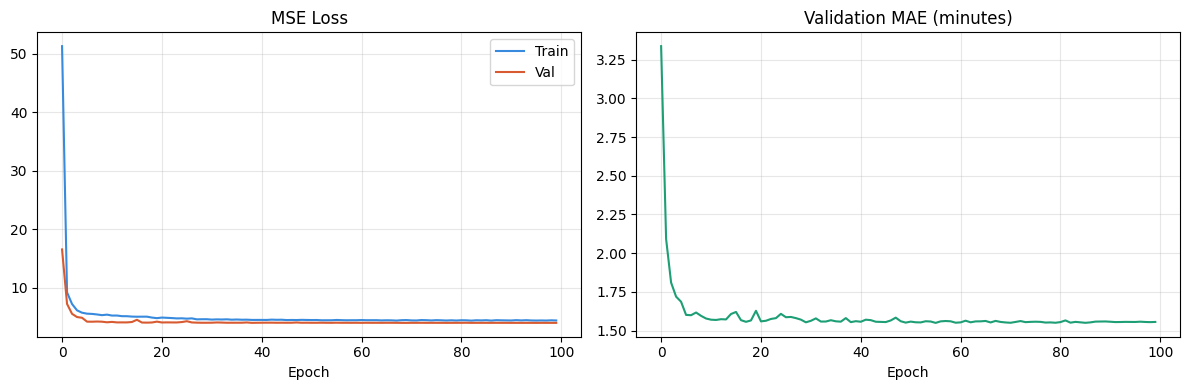

💾 Plot saved to Drive


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
import json, pickle
from pathlib import Path

# ── Dims derived from dataset ─────────────────────────────────
NODE_FEAT_DIM  = dataset[0].x.shape[1]
EDGE_FEAT_DIM  = dataset[0].edge_attr.shape[1]
EXTRA_FEAT_DIM = dataset[0].extra_features.shape[1]
HIDDEN_DIM     = 64

print(f"Node feat dim:  {NODE_FEAT_DIM}")
print(f"Edge feat dim:  {EDGE_FEAT_DIM}")
print(f"Extra feat dim: {EXTRA_FEAT_DIM}")
print(f"Hidden dim:     {HIDDEN_DIM}")


# ── Model definition ──────────────────────────────────────────
class DeliveryGNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, extra_feat_dim, hidden_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.edge_proj = nn.Linear(edge_feat_dim, hidden_dim)
        self.node_proj = nn.Linear(node_feat_dim, hidden_dim)

        self.conv1 = GATConv(hidden_dim, hidden_dim, edge_dim=hidden_dim, heads=4, concat=False)
        self.conv2 = GATConv(hidden_dim, hidden_dim, edge_dim=hidden_dim, heads=4, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + extra_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index, edge_attr, extra_features, batch):
        x         = self.node_proj(x)
        edge_attr = self.edge_proj(edge_attr)

        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        zone_embeddings = x[edge_index[1]]
        edge_batch      = batch[edge_index[1]]
        extra_expanded  = extra_features[edge_batch]

        combined = torch.cat([zone_embeddings, extra_expanded], dim=1)
        return self.fc(combined).squeeze()


# ── Init model ────────────────────────────────────────────────
gnn_model = DeliveryGNN(
    node_feat_dim=NODE_FEAT_DIM,
    edge_feat_dim=EDGE_FEAT_DIM,
    extra_feat_dim=EXTRA_FEAT_DIM,
    hidden_dim=HIDDEN_DIM,
).to(DEVICE)

total_params = sum(p.numel() for p in gnn_model.parameters() if p.requires_grad)
print(f"\n✅ Model initialised — {total_params:,} trainable parameters")


# ── Training functions ────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.extra_features.squeeze(1),
            batch.batch
        )
        active_mask = batch.edge_attr[:, 1] == 1.0
        pred_active = pred[active_mask]
        y_active    = batch.y[batch.batch[batch.edge_index[1][active_mask]]]
        loss = criterion(pred_active, y_active)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, preds_all, targets_all = 0, [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            pred  = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr,
                batch.extra_features.squeeze(1),
                batch.batch
            )
            active_mask = batch.edge_attr[:, 1] == 1.0
            pred_active = pred[active_mask]
            y_active    = batch.y[batch.batch[batch.edge_index[1][active_mask]]]
            loss = criterion(pred_active, y_active)
            total_loss += loss.item()
            preds_all.extend(pred_active.cpu().numpy())
            targets_all.extend(y_active.cpu().numpy())
    mae = np.mean(np.abs(np.array(preds_all) - np.array(targets_all)))
    return total_loss / len(loader), mae


# ── Run training ──────────────────────────────────────────────
EPOCHS    = config['gnn_epochs']
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=8, factor=0.5, min_lr=1e-5
)

best_val_loss = float('inf')
history       = {'train_loss': [], 'val_loss': [], 'val_mae': []}
CKPT_PATH     = DIRS['checkpoints'] / 'gnn_best.pt'

# ── Resume from checkpoint if exists ─────────────────────────
start_epoch = 1
if CKPT_PATH.exists():
    checkpoint    = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    gnn_model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    best_val_loss = checkpoint['best_val_loss']
    start_epoch   = checkpoint['epoch'] + 1
    history       = checkpoint['history']
    print(f"▶️  Resuming from epoch {start_epoch} (best val loss: {best_val_loss:.4f})")
else:
    print(f"🚀 Training from scratch for {EPOCHS} epochs\n")

if start_epoch <= EPOCHS:
    print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Val Loss':>10}  {'Val MAE':>8}  {'LR':>8}")
    print("─" * 52)

    for epoch in range(start_epoch, EPOCHS + 1):
        train_loss        = train_epoch(gnn_model, train_loader, optimizer, criterion)
        val_loss, val_mae = eval_epoch(gnn_model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)

        lr = optimizer.param_groups[0]['lr']

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch':           epoch,
                'model_state':     gnn_model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_val_loss':   best_val_loss,
                'history':         history,
            }, CKPT_PATH)
            tag = ' ← best'
        else:
            tag = ''

        if epoch % 5 == 0 or epoch == 1:
            print(f"{epoch:>6}  {train_loss:>10.4f}  {val_loss:>10.4f}  {val_mae:>8.2f}m  {lr:>8.6f}{tag}")
else:
    print(f"✅ Already trained for {EPOCHS} epochs — loading best checkpoint")

# ── Final eval on test set ────────────────────────────────────
gnn_model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)['model_state'])
test_loss, test_mae = eval_epoch(gnn_model, test_loader, criterion)

print(f"\n{'─'*52}")
print(f"✅ Training complete")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Test MSE loss : {test_loss:.4f}")
print(f"   Test MAE      : {test_mae:.2f} minutes")
print(f"💾 Best checkpoint saved to {CKPT_PATH}")

# ── Save history ──────────────────────────────────────────────
with open(DIRS['models'] / 'gnn_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.items()}, f, indent=2)

# ── Plot loss curves ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train', color='#378ADD')
ax1.plot(history['val_loss'],   label='Val',   color='#D85A30')
ax1.set_title('MSE Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['val_mae'], color='#1D9E75')
ax2.set_title('Validation MAE (minutes)')
ax2.set_xlabel('Epoch')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DIRS['plots'] / 'gnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Plot saved to Drive")

In [17]:
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor
import numpy as np
import json, pickle
from pathlib import Path

# ── Delivery routing environment ─────────────────────────────
class DeliveryRoutingEnv(gym.Env):
    """
    RL environment for dynamic delivery re-routing.

    State:  [hour, weekday, warehouse_id, neighborhood_id,
             current_delay_pred, alt_route_delays x5, demand, distance]
    Action: choose one of N_ROUTES alternative routes (0 = keep current)
    Reward: reduction in predicted delay vs baseline
    """

    N_ALT_ROUTES = 5  # number of alternative routes agent can pick from

    def __init__(self, orders_df, gnn_model, route_distances,
                 warehouse_nodes, neighborhood_nodes, device):
        super().__init__()

        self.orders_df          = orders_df.reset_index(drop=True)
        self.gnn_model          = gnn_model
        self.route_distances    = route_distances
        self.warehouse_nodes    = warehouse_nodes
        self.neighborhood_nodes = neighborhood_nodes
        self.device             = device

        self.warehouse_names    = list(warehouse_nodes.keys())
        self.neighborhood_names = list(neighborhood_nodes.keys())
        self.node_names         = self.warehouse_names + self.neighborhood_names
        self.node_index         = {n: i for i, n in enumerate(self.node_names)}

        # Obs: [hour, weekday, wh_id, nb_id, current_delay,
        #        alt_delay_0..4, demand, distance_norm]
        obs_dim = 5 + self.N_ALT_ROUTES + 2
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )
        # Action: 0 = keep route, 1..N_ALT_ROUTES = switch to alternative
        self.action_space = spaces.Discrete(self.N_ALT_ROUTES + 1)

        self.current_step  = 0
        self.current_order = None
        self.baseline_delay = 0.0

    # ── GNN delay prediction for a single route ───────────────
    def _predict_delay(self, warehouse, neighborhood, hour, weekday, demand):
        from torch_geometric.data import Data
        import torch

        all_nodes = {**self.warehouse_nodes, **self.neighborhood_nodes}
        NEIGHBORHOOD_WEIGHTS = {
            'Mission': 1.4, 'Castro': 1.1, 'SoMa': 1.3, 'Financial': 0.6,
            'Chinatown': 1.2, 'North Beach': 1.0, 'Marina': 1.3, 'Richmond': 1.1,
            'Sunset': 1.2, 'Haight': 1.0, 'Noe Valley': 1.2, 'Excelsior': 0.9,
            'Bayview': 0.8, 'Tenderloin': 1.1, 'Potrero Hill': 0.9,
        }

        node_features = []
        for name in self.node_names:
            info     = all_nodes[name]
            is_wh    = 1.0 if name in self.warehouse_names else 0.0
            demand_w = 0.0 if is_wh else NEIGHBORHOOD_WEIGHTS.get(name, 1.0)
            node_features.append([info['lat'] / 90.0, info['lng'] / 180.0, is_wh, demand_w])

        src_list, dst_list, edge_attrs = [], [], []
        route_pairs = [(w, n) for w in self.warehouse_names for n in self.neighborhood_names]
        for w, n in route_pairs:
            src_list.append(self.node_index[w])
            dst_list.append(self.node_index[n])
            dist      = self.route_distances.get(f"{w}__{n}", 5000.0)
            is_active = 1.0 if (w == warehouse and n == neighborhood) else 0.0
            edge_attrs.append([dist / 10000.0, is_active, hour / 23.0, weekday / 6.0])

        x          = torch.tensor(node_features, dtype=torch.float).to(self.device)
        edge_index = torch.tensor([src_list, dst_list], dtype=torch.long).to(self.device)
        edge_attr  = torch.tensor(edge_attrs, dtype=torch.float).to(self.device)
        dist_active = self.route_distances.get(f"{warehouse}__{neighborhood}", 5000.0)
        extra      = torch.tensor([[hour / 23.0, weekday / 6.0, demand,
                                    dist_active / 10000.0]], dtype=torch.float).to(self.device)
        batch      = torch.zeros(len(self.node_names), dtype=torch.long).to(self.device)

        self.gnn_model.eval()
        with torch.no_grad():
            preds = self.gnn_model(x, edge_index, edge_attr, extra, batch)

        active_mask = edge_attr[:, 1] == 1.0
        if active_mask.sum() > 0:
            return float(preds[active_mask][0].cpu())
        return 10.0

    # ── Build alternative routes ──────────────────────────────
    def _get_alternatives(self, order_row):
        wh      = order_row['warehouse']
        nb      = order_row['neighborhood']
        hour    = order_row['hour']
        weekday = order_row['weekday']
        demand  = order_row['demand']

        # Alt routes: same nb different wh, or same wh different nb
        alts = []
        for alt_wh in self.warehouse_names:
            if alt_wh != wh:
                alts.append((alt_wh, nb))
        for alt_nb in self.neighborhood_names:
            if alt_nb != nb:
                alts.append((wh, alt_nb))

        np.random.shuffle(alts)
        alts = alts[:self.N_ALT_ROUTES]

        # Pad if fewer than N_ALT_ROUTES
        while len(alts) < self.N_ALT_ROUTES:
            alts.append((wh, nb))

        alt_delays = []
        for alt_wh, alt_nb in alts:
            d = self._predict_delay(alt_wh, alt_nb, hour, weekday, demand)
            alt_delays.append(d)

        return alts, alt_delays

    # ── Gym interface ─────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step  = np.random.randint(0, len(self.orders_df))
        self.current_order = self.orders_df.iloc[self.current_step]

        wh      = self.current_order['warehouse']
        nb      = self.current_order['neighborhood']
        hour    = self.current_order['hour']
        weekday = self.current_order['weekday']
        demand  = self.current_order['demand']
        dist    = self.current_order['distance_m']

        self.baseline_delay = self._predict_delay(wh, nb, hour, weekday, demand)
        self.alts, self.alt_delays = self._get_alternatives(self.current_order)

        obs = np.array([
            hour / 23.0,
            weekday / 6.0,
            self.warehouse_names.index(wh) / len(self.warehouse_names),
            self.neighborhood_names.index(nb) / len(self.neighborhood_names),
            self.baseline_delay / 60.0,
            *[d / 60.0 for d in self.alt_delays],
            demand,
            dist / 20000.0,
        ], dtype=np.float32)

        return obs, {}

    def step(self, action):
        if action == 0:
            # Keep current route
            final_delay = self.baseline_delay
            chosen_wh   = self.current_order['warehouse']
            chosen_nb   = self.current_order['neighborhood']
        else:
            # Switch to alternative route
            chosen_wh, chosen_nb = self.alts[action - 1]
            final_delay = self.alt_delays[action - 1]

        # Reward = delay reduction (positive = improvement)
        reward = (self.baseline_delay - final_delay) / 60.0

        # Small penalty for unnecessary switching
        if action != 0 and final_delay >= self.baseline_delay:
            reward -= 0.1

        obs, _ = self.reset()
        return obs, reward, False, True, {
            'baseline_delay': self.baseline_delay,
            'final_delay':    final_delay,
            'action':         action,
            'chosen_wh':      chosen_wh,
            'chosen_nb':      chosen_nb,
        }

    def render(self):
        pass


# ── Instantiate env ───────────────────────────────────────────
with open(DIRS['data'] / 'warehouse_nodes.json') as f:
    WAREHOUSE_NODES = json.load(f)
with open(DIRS['data'] / 'neighborhood_nodes.json') as f:
    NEIGHBORHOOD_NODES = json.load(f)
with open(DIRS['data'] / 'route_distances.json') as f:
    route_distances = json.load(f)

orders_df = pd.read_csv(DIRS['orders'] / 'orders.csv', parse_dates=['timestamp'])

env = DeliveryRoutingEnv(
    orders_df=orders_df,
    gnn_model=gnn_model,
    route_distances=route_distances,
    warehouse_nodes=WAREHOUSE_NODES,
    neighborhood_nodes=NEIGHBORHOOD_NODES,
    device=DEVICE,
)
env = Monitor(env)
print("✅ Environment created")
print(f"   Obs space:    {env.observation_space.shape}")
print(f"   Action space: {env.action_space.n} actions (0=keep, 1-5=reroute)")


# ── Train RL agent ────────────────────────────────────────────
RL_CKPT_PATH = DIRS['checkpoints'] / 'ppo_delivery'
RL_LOG_PATH  = DIRS['results'] / 'ppo_logs'
RL_LOG_PATH.mkdir(exist_ok=True)

checkpoint_cb = CheckpointCallback(
    save_freq=10_000,
    save_path=str(DIRS['checkpoints']),
    name_prefix='ppo_delivery',
    verbose=1,
)

# Check for existing RL checkpoint
existing_ckpts = sorted(DIRS['checkpoints'].glob('ppo_delivery_*.zip'))

if existing_ckpts:
    latest = str(existing_ckpts[-1])
    print(f"\n▶️  Loading existing RL checkpoint: {existing_ckpts[-1].name}")
    rl_agent = PPO.load(latest, env=env)
else:
    print(f"\n🚀 Training PPO agent for {config['rl_timesteps']:,} timesteps...")
    rl_agent = PPO(
        policy='MlpPolicy',
        env=env,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,       # encourages exploration
        verbose=1,
        tensorboard_log=str(RL_LOG_PATH),
        seed=SEED,
    )

rl_agent.learn(
    total_timesteps=config['rl_timesteps'],
    callback=checkpoint_cb,
    reset_num_timesteps=False,
)

rl_agent.save(str(DIRS['models'] / 'ppo_final'))
print(f"\n✅ RL agent trained & saved to Drive")


# ── Evaluate RL agent ─────────────────────────────────────────
print("\n── Evaluating RL agent on 500 episodes ──")
n_eval      = 500
rewards     = []
delays_before, delays_after = [], []
reroute_count = 0

obs, _ = env.reset()
for _ in range(n_eval):
    action, _ = rl_agent.predict(obs, deterministic=True)
    obs, reward, _, _, info = env.step(action)
    rewards.append(reward)
    delays_before.append(info['baseline_delay'])
    delays_after.append(info['final_delay'])
    if info['action'] != 0:
        reroute_count += 1

avg_delay_before = np.mean(delays_before)
avg_delay_after  = np.mean(delays_after)
avg_improvement  = avg_delay_before - avg_delay_after
reroute_rate     = reroute_count / n_eval * 100

print(f"   Avg delay before rerouting : {avg_delay_before:.2f} min")
print(f"   Avg delay after rerouting  : {avg_delay_after:.2f} min")
print(f"   Avg improvement            : {avg_improvement:.2f} min")
print(f"   Reroute rate               : {reroute_rate:.1f}%")
print(f"   Avg reward                 : {np.mean(rewards):.4f}")

# Save eval results
eval_results = {
    'avg_delay_before': float(avg_delay_before),
    'avg_delay_after':  float(avg_delay_after),
    'avg_improvement':  float(avg_improvement),
    'reroute_rate':     float(reroute_rate),
    'avg_reward':       float(np.mean(rewards)),
}
with open(DIRS['results'] / 'rl_eval.json', 'w') as f:
    json.dump(eval_results, f, indent=2)
print(f"💾 Eval results saved to Drive")

# ── Plot ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(delays_before, bins=40, alpha=0.6, label='Before', color='#D85A30')
ax1.hist(delays_after,  bins=40, alpha=0.6, label='After',  color='#1D9E75')
ax1.set_title('Delay distribution before vs after rerouting')
ax1.set_xlabel('Delay (minutes)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(np.cumsum(rewards) / (np.arange(len(rewards)) + 1), color='#378ADD')
ax2.set_title('Cumulative avg reward over evaluation')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Avg reward')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DIRS['plots'] / 'rl_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Plot saved to Drive")

✅ Environment created
   Obs space:    (12,)
   Action space: 6 actions (0=keep, 1-5=reroute)

🚀 Training PPO agent for 200,000 timesteps...
Using cuda device
Wrapping the env in a DummyVecEnv.
Logging to /content/drive/MyDrive/SF_Delivery_Optimization/results/ppo_logs/PPO_0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | -0.0945  |
| time/              |          |
|    fps             | 17       |
|    iterations      | 1        |
|    time_elapsed    | 117      |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1           |
|    ep_rew_mean          | -0.0776     |
| time/                   |             |
|    fps                  | 17          |
|    iterations           | 2           |
|    time_elapsed         | 233         |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010272331 |
|    clip_fraction        | 0.0627      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.78       |
|    explained_variance   | -0.935      |
|    learning_rate        | 0.

KeyboardInterrupt: 

In [18]:
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.monitor import Monitor
import numpy as np
import json, pickle
from pathlib import Path
from tqdm.auto import tqdm

# ── Load data ─────────────────────────────────────────────────
with open(DIRS['data'] / 'warehouse_nodes.json') as f:
    WAREHOUSE_NODES = json.load(f)
with open(DIRS['data'] / 'neighborhood_nodes.json') as f:
    NEIGHBORHOOD_NODES = json.load(f)
with open(DIRS['data'] / 'route_distances.json') as f:
    route_distances = json.load(f)

orders_df = pd.read_csv(DIRS['orders'] / 'orders.csv', parse_dates=['timestamp'])

WAREHOUSE_NAMES    = list(WAREHOUSE_NODES.keys())
NEIGHBORHOOD_NAMES = list(NEIGHBORHOOD_NODES.keys())
ALL_NODES          = {**WAREHOUSE_NODES, **NEIGHBORHOOD_NODES}
NODE_NAMES         = WAREHOUSE_NAMES + NEIGHBORHOOD_NAMES
NODE_INDEX         = {n: i for i, n in enumerate(NODE_NAMES)}
ROUTE_PAIRS        = [(w, n) for w in WAREHOUSE_NAMES for n in NEIGHBORHOOD_NAMES]

HOUR_DEMAND = {
    0: 0.05, 1: 0.02, 2: 0.01, 3: 0.01, 4: 0.02, 5: 0.05,
    6: 0.10, 7: 0.20, 8: 0.30, 9: 0.40, 10: 0.55, 11: 0.75,
    12: 0.90, 13: 0.80, 14: 0.60, 15: 0.55, 16: 0.65, 17: 0.85,
    18: 1.00, 19: 0.95, 20: 0.80, 21: 0.60, 22: 0.35, 23: 0.15,
}
DAY_DEMAND = {0: 0.70, 1: 0.65, 2: 0.70, 3: 0.75, 4: 0.90, 5: 1.00, 6: 0.95}
NEIGHBORHOOD_WEIGHTS = {
    'Mission': 1.4, 'Castro': 1.1, 'SoMa': 1.3, 'Financial': 0.6,
    'Chinatown': 1.2, 'North Beach': 1.0, 'Marina': 1.3, 'Richmond': 1.1,
    'Sunset': 1.2, 'Haight': 1.0, 'Noe Valley': 1.2, 'Excelsior': 0.9,
    'Bayview': 0.8, 'Tenderloin': 1.1, 'Potrero Hill': 0.9,
}


# ── Step 1: Precompute GNN predictions (runs once, cached) ────
CACHE_PATH = DIRS['data'] / 'delay_cache.pkl'

if CACHE_PATH.exists():
    with open(CACHE_PATH, 'rb') as f:
        delay_cache = pickle.load(f)
    print(f"📂 Loaded delay cache ({len(delay_cache)} entries)")

else:
    print("⚙️  Precomputing GNN predictions for all hour/day/route combos...")
    delay_cache = {}
    gnn_model.eval()

    for hour in tqdm(range(24), desc='Hours'):
        for weekday in range(7):
            for wh in WAREHOUSE_NAMES:
                for nb in NEIGHBORHOOD_NAMES:
                    demand = (HOUR_DEMAND[hour] * DAY_DEMAND[weekday]
                              * NEIGHBORHOOD_WEIGHTS.get(nb, 1.0))

                    node_features = []
                    for name in NODE_NAMES:
                        info     = ALL_NODES[name]
                        is_wh    = 1.0 if name in WAREHOUSE_NAMES else 0.0
                        demand_w = 0.0 if is_wh else NEIGHBORHOOD_WEIGHTS.get(name, 1.0)
                        node_features.append([
                            info['lat'] / 90.0, info['lng'] / 180.0, is_wh, demand_w
                        ])

                    src_list, dst_list, edge_attrs = [], [], []
                    for w, n in ROUTE_PAIRS:
                        src_list.append(NODE_INDEX[w])
                        dst_list.append(NODE_INDEX[n])
                        dist      = route_distances.get(f"{w}__{n}", 5000.0)
                        is_active = 1.0 if (w == wh and n == nb) else 0.0
                        edge_attrs.append([
                            dist / 10000.0, is_active,
                            hour / 23.0, weekday / 6.0
                        ])

                    x          = torch.tensor(node_features, dtype=torch.float).to(DEVICE)
                    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long).to(DEVICE)
                    edge_attr  = torch.tensor(edge_attrs, dtype=torch.float).to(DEVICE)
                    dist_active = route_distances.get(f"{wh}__{nb}", 5000.0)
                    extra      = torch.tensor([[
                        hour / 23.0, weekday / 6.0, demand, dist_active / 10000.0
                    ]], dtype=torch.float).to(DEVICE)
                    batch      = torch.zeros(len(NODE_NAMES), dtype=torch.long).to(DEVICE)

                    with torch.no_grad():
                        preds = gnn_model(x, edge_index, edge_attr, extra, batch)

                    active_mask = edge_attr[:, 1] == 1.0
                    pred_val    = float(preds[active_mask][0].cpu()) if active_mask.sum() > 0 else 10.0
                    delay_cache[(hour, weekday, wh, nb)] = pred_val

    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(delay_cache, f)
    print(f"✅ Cached {len(delay_cache)} predictions to Drive")


# ── Step 2: Fast env using cache lookup ───────────────────────
class FastDeliveryRoutingEnv(gym.Env):
    N_ALT_ROUTES = 5

    def __init__(self, orders_df, delay_cache, warehouse_names, neighborhood_names):
        super().__init__()
        self.orders_df          = orders_df.reset_index(drop=True)
        self.delay_cache        = delay_cache
        self.warehouse_names    = warehouse_names
        self.neighborhood_names = neighborhood_names

        obs_dim = 5 + self.N_ALT_ROUTES + 2
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(self.N_ALT_ROUTES + 1)

    def _get_delay(self, wh, nb, hour, weekday):
        return self.delay_cache.get((hour, weekday, wh, nb), 10.0)

    def _get_alternatives(self, wh, nb, hour, weekday):
        alts = []
        for alt_wh in self.warehouse_names:
            if alt_wh != wh:
                alts.append((alt_wh, nb))
        for alt_nb in self.neighborhood_names:
            if alt_nb != nb:
                alts.append((wh, alt_nb))
        np.random.shuffle(alts)
        alts = alts[:self.N_ALT_ROUTES]
        while len(alts) < self.N_ALT_ROUTES:
            alts.append((wh, nb))
        return alts, [self._get_delay(w, n, hour, weekday) for w, n in alts]

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        idx   = np.random.randint(0, len(self.orders_df))
        order = self.orders_df.iloc[idx]

        self.wh      = order['warehouse']
        self.nb      = order['neighborhood']
        self.hour    = int(order['hour'])
        self.weekday = int(order['weekday'])
        self.demand  = float(order['demand'])
        self.dist    = float(order['distance_m'])

        self.baseline_delay        = self._get_delay(self.wh, self.nb, self.hour, self.weekday)
        self.alts, self.alt_delays = self._get_alternatives(
            self.wh, self.nb, self.hour, self.weekday
        )

        obs = np.array([
            self.hour / 23.0,
            self.weekday / 6.0,
            self.warehouse_names.index(self.wh) / len(self.warehouse_names),
            self.neighborhood_names.index(self.nb) / len(self.neighborhood_names),
            self.baseline_delay / 60.0,
            *[d / 60.0 for d in self.alt_delays],
            self.demand,
            self.dist / 20000.0,
        ], dtype=np.float32)
        return obs, {}

    def step(self, action):
        if action == 0:
            final_delay          = self.baseline_delay
            chosen_wh, chosen_nb = self.wh, self.nb
        else:
            chosen_wh, chosen_nb = self.alts[action - 1]
            final_delay          = self.alt_delays[action - 1]

        reward = (self.baseline_delay - final_delay) / 60.0
        if action != 0 and final_delay >= self.baseline_delay:
            reward -= 0.1

        obs, _ = self.reset()
        return obs, reward, False, True, {
            'baseline_delay': self.baseline_delay,
            'final_delay':    final_delay,
            'action':         action,
            'chosen_wh':      chosen_wh,
            'chosen_nb':      chosen_nb,
        }

    def render(self):
        pass


# ── Step 3: Create env ────────────────────────────────────────
fast_env = FastDeliveryRoutingEnv(
    orders_df=orders_df,
    delay_cache=delay_cache,
    warehouse_names=WAREHOUSE_NAMES,
    neighborhood_names=NEIGHBORHOOD_NAMES,
)
fast_env = Monitor(fast_env)
print(f"✅ Fast env ready")
print(f"   Obs space:    {fast_env.observation_space.shape}")
print(f"   Action space: {fast_env.action_space.n} (0=keep, 1-5=reroute)")


# ── Step 4: Train PPO ─────────────────────────────────────────
RL_CKPT_DIR = DIRS['checkpoints']
existing    = sorted(RL_CKPT_DIR.glob('ppo_fast_*.zip'))

if existing:
    print(f"\n▶️  Loading checkpoint: {existing[-1].name}")
    rl_agent = PPO.load(str(existing[-1]), env=fast_env)
    reset_timesteps = False
else:
    print(f"\n🚀 Training PPO for {config['rl_timesteps']:,} timesteps...")
    rl_agent = PPO(
        policy='MlpPolicy',
        env=fast_env,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        verbose=1,
        seed=SEED,
    )
    reset_timesteps = True

rl_agent.learn(
    total_timesteps=config['rl_timesteps'],
    callback=CheckpointCallback(
        save_freq=10_000,
        save_path=str(RL_CKPT_DIR),
        name_prefix='ppo_fast',
        verbose=0,
    ),
    reset_num_timesteps=reset_timesteps,
)

rl_agent.save(str(DIRS['models'] / 'ppo_final'))
print(f"\n✅ RL agent trained & saved to Drive")

⚙️  Precomputing GNN predictions for all hour/day/route combos...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Hours:   0%|          | 0/24 [00:00<?, ?it/s]

✅ Cached 7560 predictions to Drive
✅ Fast env ready
   Obs space:    (12,)
   Action space: 6 (0=keep, 1-5=reroute)

🚀 Training PPO for 200,000 timesteps...
Using cuda device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | -0.0822  |
| time/              |          |
|    fps             | 465      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1           |
|    ep_rew_mean          | -0.078      |
| time/                   |             |
|    fps                  | 354         |
|    iterations           | 2           |
|    time_elapsed         | 11          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.

RuntimeError: Tried to step environment that needs reset

In [19]:
# ── Step 5: Evaluate ──────────────────────────────────────────
print("\n── Evaluating RL agent on 500 episodes ──")
n_eval        = 500
rewards       = []
delays_before = []
delays_after  = []
reroute_count = 0

obs, _ = fast_env.reset()  # reset after training
for _ in range(n_eval):
    action, _            = rl_agent.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = fast_env.step(action)
    rewards.append(reward)
    delays_before.append(info['baseline_delay'])
    delays_after.append(info['final_delay'])
    if info['action'] != 0:
        reroute_count += 1
    if terminated or truncated:
        obs, _ = fast_env.reset()

avg_before   = np.mean(delays_before)
avg_after    = np.mean(delays_after)
improvement  = avg_before - avg_after
reroute_rate = reroute_count / n_eval * 100

print(f"   Avg delay before : {avg_before:.2f} min")
print(f"   Avg delay after  : {avg_after:.2f} min")
print(f"   Improvement      : {improvement:.2f} min")
print(f"   Reroute rate     : {reroute_rate:.1f}%")
print(f"   Avg reward       : {np.mean(rewards):.4f}")

with open(DIRS['results'] / 'rl_eval.json', 'w') as f:
    json.dump({
        'avg_delay_before': float(avg_before),
        'avg_delay_after':  float(avg_after),
        'avg_improvement':  float(improvement),
        'reroute_rate':     float(reroute_rate),
        'avg_reward':       float(np.mean(rewards)),
    }, f, indent=2)
print(f"💾 Eval results saved to Drive")


── Evaluating RL agent on 500 episodes ──
   Avg delay before : 15.94 min
   Avg delay after  : 13.87 min
   Improvement      : 2.06 min
   Reroute rate     : 54.6%
   Avg reward       : 0.0334
💾 Eval results saved to Drive


In [24]:
import folium
from folium import plugins
import json, pickle
import numpy as np
import osmnx as ox
import networkx as nx
from pathlib import Path
from IPython.display import HTML

# ── Load everything ───────────────────────────────────────────
with open(DIRS['data'] / 'warehouse_nodes.json') as f:
    WAREHOUSE_NODES = json.load(f)
with open(DIRS['data'] / 'neighborhood_nodes.json') as f:
    NEIGHBORHOOD_NODES = json.load(f)
with open(DIRS['data'] / 'route_distances.json') as f:
    route_distances = json.load(f)
with open(DIRS['data'] / 'delay_cache.pkl', 'rb') as f:
    delay_cache = pickle.load(f)
with open(DIRS['results'] / 'rl_eval.json') as f:
    rl_eval = json.load(f)
with open(DIRS['graph'] / 'sf_road_network.pkl', 'rb') as f:
    G = pickle.load(f)

orders_df = pd.read_csv(DIRS['orders'] / 'orders.csv', parse_dates=['timestamp'])

WAREHOUSE_NAMES    = list(WAREHOUSE_NODES.keys())
NEIGHBORHOOD_NAMES = list(NEIGHBORHOOD_NODES.keys())

NEIGHBORHOOD_WEIGHTS = {
    'Mission': 1.4, 'Castro': 1.1, 'SoMa': 1.3, 'Financial': 0.6,
    'Chinatown': 1.2, 'North Beach': 1.0, 'Marina': 1.3, 'Richmond': 1.1,
    'Sunset': 1.2, 'Haight': 1.0, 'Noe Valley': 1.2, 'Excelsior': 0.9,
    'Bayview': 0.8, 'Tenderloin': 1.1, 'Potrero Hill': 0.9,
}

print("✅ All data loaded")


# ── Helper: get actual road path coords ──────────────────────
def get_route_coords(G, orig_node, dest_node):
    try:
        path   = nx.shortest_path(G, orig_node, dest_node, weight='length')
        coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path]
        return coords
    except nx.NetworkXNoPath:
        return [
            (G.nodes[orig_node]['y'], G.nodes[orig_node]['x']),
            (G.nodes[dest_node]['y'], G.nodes[dest_node]['x']),
        ]


# ── Pick worst/best routes for a given hour/day ───────────────
def get_worst_best_routes(hour, weekday):
    delays = {
        (wh, nb): delay_cache.get((hour, weekday, wh, nb), 10.0)
        for wh in WAREHOUSE_NAMES
        for nb in NEIGHBORHOOD_NAMES
    }
    sorted_routes = sorted(delays.items(), key=lambda x: x[1], reverse=True)
    return sorted_routes[:3], sorted_routes[-3:]


# ── Build map ─────────────────────────────────────────────────
sf_center = [37.7749, -122.4194]
m = folium.Map(location=sf_center, zoom_start=13, tiles='CartoDB positron')

# ── Layer groups ──────────────────────────────────────────────
wh_layer       = folium.FeatureGroup(name='Warehouses',              show=True)
nb_layer       = folium.FeatureGroup(name='Neighborhoods',           show=True)
delayed_layer  = folium.FeatureGroup(name='Delayed routes (red)',    show=True)
optimal_layer  = folium.FeatureGroup(name='Optimal routes (green)',  show=True)
rerouted_layer = folium.FeatureGroup(name='RL rerouted (blue)',      show=True)
heatmap_layer  = folium.FeatureGroup(name='Demand heatmap',          show=False)


# ── Warehouse markers ─────────────────────────────────────────
for name, info in WAREHOUSE_NODES.items():
    color = 'blue' if 'North' in name else ('green' if 'Central' in name else 'red')
    folium.Marker(
        location=[info['lat'], info['lng']],
        popup=folium.Popup(f"""
            <b>{name}</b><br>
            Type: Warehouse<br>
            Lat: {info['lat']:.4f}<br>
            Lng: {info['lng']:.4f}
        """, max_width=200),
        tooltip=name,
        icon=folium.Icon(color=color, icon='home', prefix='fa')
    ).add_to(wh_layer)


# ── Neighborhood markers ──────────────────────────────────────
for name, info in NEIGHBORHOOD_NODES.items():
    weight    = NEIGHBORHOOD_WEIGHTS.get(name, 1.0)
    n_orders  = len(orders_df[orders_df['neighborhood'] == name])
    avg_delay = orders_df[orders_df['neighborhood'] == name]['delay_min'].mean()
    folium.CircleMarker(
        location=[info['lat'], info['lng']],
        radius=8 + weight * 4,
        color='#444',
        weight=1,
        fill=True,
        fill_color='#EF9F27',
        fill_opacity=0.8,
        popup=folium.Popup(f"""
            <b>{name}</b><br>
            Demand weight: {weight}<br>
            Total orders: {n_orders:,}<br>
            Avg delay: {avg_delay:.1f} min
        """, max_width=200),
        tooltip=f"{name} ({n_orders} orders)",
    ).add_to(nb_layer)


# ── Delayed routes — red animated ────────────────────────────
peak_hour, peak_day  = 18, 4
worst_routes, best_routes = get_worst_best_routes(peak_hour, peak_day)

for (wh, nb), delay in worst_routes:
    orig_node = WAREHOUSE_NODES[wh]['node_id']
    dest_node = NEIGHBORHOOD_NODES[nb]['node_id']
    coords    = get_route_coords(G, orig_node, dest_node)
    dist_km   = route_distances.get(f"{wh}__{nb}", 0) / 1000
    folium.PolyLine(
        locations=coords, color='#E24B4A', weight=4, opacity=0.8,
        tooltip=f"DELAYED: {wh}→{nb} | {delay:.1f} min | {dist_km:.1f} km",
        popup=folium.Popup(f"""
            <b>Delayed Route</b><br>
            From: {wh}<br>To: {nb}<br>
            Predicted delay: <b>{delay:.1f} min</b><br>
            Distance: {dist_km:.1f} km<br>
            Time: Friday 6pm (peak)
        """, max_width=220)
    ).add_to(delayed_layer)
    plugins.AntPath(
        locations=coords, color='#E24B4A', weight=3, opacity=0.5, delay=1000
    ).add_to(delayed_layer)


# ── Optimal routes — green ────────────────────────────────────
for (wh, nb), delay in best_routes:
    orig_node = WAREHOUSE_NODES[wh]['node_id']
    dest_node = NEIGHBORHOOD_NODES[nb]['node_id']
    coords    = get_route_coords(G, orig_node, dest_node)
    dist_km   = route_distances.get(f"{wh}__{nb}", 0) / 1000
    folium.PolyLine(
        locations=coords, color='#1D9E75', weight=4, opacity=0.8,
        tooltip=f"OPTIMAL: {wh}→{nb} | {delay:.1f} min | {dist_km:.1f} km",
        popup=folium.Popup(f"""
            <b>Optimal Route</b><br>
            From: {wh}<br>To: {nb}<br>
            Predicted delay: <b>{delay:.1f} min</b><br>
            Distance: {dist_km:.1f} km<br>
            Time: Friday 6pm (peak)
        """, max_width=220)
    ).add_to(optimal_layer)


# ── RL rerouted routes — blue dashed ─────────────────────────
reroute_examples = []
for nb in NEIGHBORHOOD_NAMES:
    for wh in WAREHOUSE_NAMES:
        orig_delay    = delay_cache.get((peak_hour, peak_day, wh, nb), 10.0)
        best_alt_delay = orig_delay
        best_alt_wh   = wh
        for alt_wh in WAREHOUSE_NAMES:
            if alt_wh != wh:
                alt_delay = delay_cache.get((peak_hour, peak_day, alt_wh, nb), 10.0)
                if alt_delay < best_alt_delay:
                    best_alt_delay = alt_delay
                    best_alt_wh    = alt_wh
        saving = orig_delay - best_alt_delay
        if saving > 0.5:
            reroute_examples.append((wh, best_alt_wh, nb, orig_delay, best_alt_delay, saving))

reroute_examples = sorted(reroute_examples, key=lambda x: x[5], reverse=True)[:4]

for orig_wh, new_wh, nb, orig_delay, new_delay, saving in reroute_examples:
    orig_node = WAREHOUSE_NODES[new_wh]['node_id']
    dest_node = NEIGHBORHOOD_NODES[nb]['node_id']
    coords    = get_route_coords(G, orig_node, dest_node)
    dist_km   = route_distances.get(f"{new_wh}__{nb}", 0) / 1000
    folium.PolyLine(
        locations=coords, color='#185FA5', weight=5, opacity=0.9,
        dash_array='10',
        tooltip=f"RL REROUTED: {new_wh}→{nb} | saved {saving:.1f} min",
        popup=folium.Popup(f"""
            <b>RL Rerouted</b><br>
            Original: {orig_wh}<br>
            Rerouted to: {new_wh}<br>
            Destination: {nb}<br>
            Original delay: {orig_delay:.1f} min<br>
            New delay: <b>{new_delay:.1f} min</b><br>
            <b>Saved: {saving:.1f} min</b>
        """, max_width=220)
    ).add_to(rerouted_layer)


# ── Demand heatmap ────────────────────────────────────────────
heat_data = []
for name, info in NEIGHBORHOOD_NODES.items():
    weight = NEIGHBORHOOD_WEIGHTS.get(name, 1.0)
    for _ in range(int(weight * 10)):
        heat_data.append([
            info['lat'] + np.random.normal(0, 0.003),
            info['lng'] + np.random.normal(0, 0.003),
            weight,
        ])

plugins.HeatMap(
    heat_data, min_opacity=0.3, radius=25, blur=20,
    gradient={0.2: '#1D9E75', 0.5: '#EF9F27', 0.8: '#E24B4A'},
).add_to(heatmap_layer)


# ── Legend box ────────────────────────────────────────────────
legend_html = f"""
<div style="
    position: fixed; bottom: 30px; left: 30px;
    background: white; border: 1px solid #ccc;
    border-radius: 8px; padding: 14px 18px;
    font-family: Arial, sans-serif; font-size: 13px;
    z-index: 1000; box-shadow: 0 2px 8px rgba(0,0,0,0.15);
    min-width: 220px;">
    <b style="font-size:14px">SF Delivery Optimizer</b><br>
    <hr style="margin:6px 0; border-color:#eee">
    <span style="color:#E24B4A">&#9644;</span> Delayed routes<br>
    <span style="color:#1D9E75">&#9644;</span> Optimal routes<br>
    <span style="color:#185FA5">&#9644;</span> RL rerouted (dashed)<br>
    <span style="color:#EF9F27">&#11044;</span> Neighborhoods<br>
    <span style="color:#444">&#9962;</span> Warehouses<br>
    <hr style="margin:6px 0; border-color:#eee">
    <b>RL Agent Results</b><br>
    Avg delay before: {rl_eval['avg_delay_before']:.1f} min<br>
    Avg delay after: {rl_eval['avg_delay_after']:.1f} min<br>
    Improvement: <b>{rl_eval['avg_improvement']:.1f} min</b><br>
    Reroute rate: {rl_eval['reroute_rate']:.1f}%
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))


# ── Add layers + control ──────────────────────────────────────
wh_layer.add_to(m)
nb_layer.add_to(m)
delayed_layer.add_to(m)
optimal_layer.add_to(m)
rerouted_layer.add_to(m)
heatmap_layer.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)


# ── Save to Drive ─────────────────────────────────────────────
MAP_PATH = DIRS['plots'] / 'sf_delivery_map.html'
m.save(str(MAP_PATH))
print(f"✅ Map saved to {MAP_PATH}")


# ── Display inline in Colab ───────────────────────────────────
with open(MAP_PATH, 'r') as f:
    map_html = f.read()

✅ All data loaded
✅ Map saved to /content/drive/MyDrive/SF_Delivery_Optimization/plots/sf_delivery_map.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
import folium
from IPython.display import display, HTML
import base64

with open(DIRS['plots'] / 'sf_delivery_map.html', 'rb') as f:
    map_bytes = f.read()

b64 = base64.b64encode(map_bytes).decode()
iframe = f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600" frameborder="0"></iframe>'
display(HTML(iframe))